In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")

In [7]:
orders.head()
orders.shape
orders.info()
orders.describe()
orders.isnull().sum()
orders.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


np.int64(0)

In [8]:
df = orders.merge(items, on="order_id", how="left")

df = df.merge(
    customers,
    on="customer_id",
    how="left"
)

df = df.merge(
    sellers,
    on="seller_id",
    how="left",
    suffixes=("_customer", "_seller")
)

df = df.merge(
    products,
    on="product_id",
    how="left"
)

df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  object 
 1   customer_id                    113425 non-null  object 
 2   order_status                   113425 non-null  object 
 3   order_purchase_timestamp       113425 non-null  object 
 4   order_approved_at              113264 non-null  object 
 5   order_delivered_carrier_date   111457 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  113425 non-null  object 
 8   order_item_id                  112650 non-null  float64
 9   product_id                     112650 non-null  object 
 10  seller_id                      112650 non-null  object 
 11  shipping_limit_date            112650 non-null  object 
 12  price                         

In [9]:
import os
import numpy as np
import pandas as pd

def clean_olist_data(df, save_path=None):
    """
    Clean and preprocess the merged Olist logistics dataframe.

    Parameters
    ----------
    df : pandas.DataFrame
        Merged dataframe created in Step 4.

    save_path : str, optional
        Location where the cleaned CSV file will be saved.

    Returns
    -------
    df_clean : pandas.DataFrame
        Cleaned item-level dataframe.

    cleaning_report : pandas.DataFrame
        Summary of rows removed during each cleaning stage.
    """

    # --------------------------------------------------------
    # 1. Create a copy of the original dataframe
    # --------------------------------------------------------

    df_clean = df.copy()

    cleaning_steps = []

    def record_step(step_name, rows_before, rows_after):
        """Store the number of rows removed at each stage."""

        cleaning_steps.append({
            "cleaning_step": step_name,
            "rows_before": rows_before,
            "rows_after": rows_after,
            "rows_removed": rows_before - rows_after
        })

    print("=" * 70)
    print("STEP 6: DATA CLEANING AND PREPROCESSING")
    print("=" * 70)

    print(f"Initial number of rows: {len(df_clean):,}")
    print(f"Initial number of columns: {df_clean.shape[1]:,}")

    # --------------------------------------------------------
    # 2. Check that essential columns exist
    # --------------------------------------------------------

    required_columns = [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "price",
        "freight_value"
    ]

    missing_required_columns = [
        column
        for column in required_columns
        if column not in df_clean.columns
    ]

    if missing_required_columns:
        raise KeyError(
            "The following required columns are missing: "
            + ", ".join(missing_required_columns)
        )

    print("\nAll essential columns are available.")

    # --------------------------------------------------------
    # 3. Standardise text columns
    # --------------------------------------------------------

    rows_before = len(df_clean)

    text_columns = df_clean.select_dtypes(
        include=["object", "string"]
    ).columns

    for column in text_columns:
        df_clean[column] = (
            df_clean[column]
            .astype("string")
            .str.strip()
        )

        # Convert empty or invalid text into missing values
        df_clean[column] = df_clean[column].replace({
            "": pd.NA,
            "nan": pd.NA,
            "NaN": pd.NA,
            "None": pd.NA,
            "null": pd.NA
        })

    record_step(
        "Standardise text values",
        rows_before,
        len(df_clean)
    )

    # --------------------------------------------------------
    # 4. Convert date columns
    # --------------------------------------------------------

    date_columns = [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]

    existing_date_columns = [
        column
        for column in date_columns
        if column in df_clean.columns
    ]

    for column in existing_date_columns:
        df_clean[column] = pd.to_datetime(
            df_clean[column],
            errors="coerce"
        )

    print("\nDate columns converted:")
    for column in existing_date_columns:
        print(f"- {column}")

    # --------------------------------------------------------
    # 5. Keep only delivered orders
    # --------------------------------------------------------

    rows_before = len(df_clean)

    df_clean["order_status"] = (
        df_clean["order_status"]
        .str.lower()
    )

    df_clean = df_clean[
        df_clean["order_status"] == "delivered"
    ].copy()

    record_step(
        "Keep delivered orders only",
        rows_before,
        len(df_clean)
    )

    # --------------------------------------------------------
    # 6. Remove records without essential dates
    # --------------------------------------------------------

    rows_before = len(df_clean)

    essential_date_columns = [
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]

    df_clean = df_clean.dropna(
        subset=essential_date_columns
    ).copy()

    record_step(
        "Remove records with missing essential dates",
        rows_before,
        len(df_clean)
    )

    # --------------------------------------------------------
    # 7. Remove records with impossible date sequences
    # --------------------------------------------------------

    rows_before = len(df_clean)

    valid_purchase_and_delivery = (
        df_clean["order_delivered_customer_date"]
        >= df_clean["order_purchase_timestamp"]
    )

    valid_purchase_and_estimate = (
        df_clean["order_estimated_delivery_date"]
        >= df_clean["order_purchase_timestamp"]
    )

    df_clean = df_clean[
        valid_purchase_and_delivery
        & valid_purchase_and_estimate
    ].copy()

    record_step(
        "Remove impossible date sequences",
        rows_before,
        len(df_clean)
    )

    # --------------------------------------------------------
    # 8. Create the prediction target safely
    # --------------------------------------------------------
    # 1 = delivered after estimated date
    # 0 = delivered on or before estimated date

    df_clean["late_delivery"] = (
        df_clean["order_delivered_customer_date"]
        > df_clean["order_estimated_delivery_date"]
    ).astype("int8")

    # Actual delay is useful for EDA only.
    # Do not use this column as a model input.

    df_clean["actual_delay_days"] = (
        df_clean["order_delivered_customer_date"]
        - df_clean["order_estimated_delivery_date"]
    ).dt.days

    # --------------------------------------------------------
    # 9. Remove exact duplicate rows
    # --------------------------------------------------------

    rows_before = len(df_clean)

    df_clean = df_clean.drop_duplicates().copy()

    record_step(
        "Remove exact duplicate rows",
        rows_before,
        len(df_clean)
    )

    # --------------------------------------------------------
    # 10. Remove duplicate order-item records
    # --------------------------------------------------------
    # Each combination of order_id and order_item_id should
    # normally represent one item within one order.

    if "order_item_id" in df_clean.columns:

        rows_before = len(df_clean)

        duplicated_order_items = df_clean.duplicated(
            subset=["order_id", "order_item_id"],
            keep="first"
        )

        duplicate_count = duplicated_order_items.sum()

        if duplicate_count > 0:
            df_clean = df_clean[
                ~duplicated_order_items
            ].copy()

        record_step(
            "Remove duplicate order-item records",
            rows_before,
            len(df_clean)
        )

    # --------------------------------------------------------
    # 11. Convert numerical columns
    # --------------------------------------------------------

    numerical_columns = [
        "order_item_id",
        "price",
        "freight_value",
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm",
        "customer_zip_code_prefix",
        "seller_zip_code_prefix"
    ]

    existing_numerical_columns = [
        column
        for column in numerical_columns
        if column in df_clean.columns
    ]

    for column in existing_numerical_columns:
        df_clean[column] = pd.to_numeric(
            df_clean[column],
            errors="coerce"
        )

    # Replace positive and negative infinity with missing values
    df_clean = df_clean.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # --------------------------------------------------------
    # 12. Remove records without price or freight information
    # --------------------------------------------------------

    rows_before = len(df_clean)

    df_clean = df_clean.dropna(
        subset=["price", "freight_value"]
    ).copy()

    record_step(
        "Remove missing price or freight records",
        rows_before,
        len(df_clean)
    )

    # --------------------------------------------------------
    # 13. Remove invalid price and freight values
    # --------------------------------------------------------

    rows_before = len(df_clean)

    valid_financial_values = (
        (df_clean["price"] >= 0)
        & (df_clean["freight_value"] >= 0)
    )

    df_clean = df_clean[
        valid_financial_values
    ].copy()

    record_step(
        "Remove negative price or freight values",
        rows_before,
        len(df_clean)
    )

    # --------------------------------------------------------
    # 14. Mark invalid product measurements as missing
    # --------------------------------------------------------

    product_measurement_columns = [
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]

    existing_measurement_columns = [
        column
        for column in product_measurement_columns
        if column in df_clean.columns
    ]

    for column in existing_measurement_columns:
        # Weight and dimensions should be greater than zero
        df_clean.loc[
            df_clean[column] <= 0,
            column
        ] = np.nan

    # --------------------------------------------------------
    # 15. Clean product category
    # --------------------------------------------------------

    if "product_category_name" in df_clean.columns:
        df_clean["product_category_name"] = (
            df_clean["product_category_name"]
            .fillna("unknown")
            .str.lower()
            .str.strip()
        )

    # --------------------------------------------------------
    # 16. Fill missing product measurements
    # --------------------------------------------------------
    # First use the median of the same product category.
    # If the category median is unavailable, use the global
    # median of the entire column.

    for column in existing_measurement_columns:

        if "product_category_name" in df_clean.columns:

            category_median = (
                df_clean
                .groupby("product_category_name")[column]
                .transform("median")
            )

            df_clean[column] = (
                df_clean[column]
                .fillna(category_median)
            )

        global_median = df_clean[column].median()

        if pd.isna(global_median):
            global_median = 0

        df_clean[column] = (
            df_clean[column]
            .fillna(global_median)
        )

    # --------------------------------------------------------
    # 17. Fill other numerical columns
    # --------------------------------------------------------

    optional_numerical_columns = [
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty"
    ]

    for column in optional_numerical_columns:

        if column in df_clean.columns:
            column_median = df_clean[column].median()

            if pd.isna(column_median):
                column_median = 0

            df_clean[column] = (
                df_clean[column]
                .fillna(column_median)
            )

    # --------------------------------------------------------
    # 18. Clean categorical columns
    # --------------------------------------------------------

    categorical_columns = [
        "product_category_name",
        "customer_city",
        "customer_state",
        "seller_city",
        "seller_state"
    ]

    for column in categorical_columns:

        if column in df_clean.columns:
            df_clean[column] = (
                df_clean[column]
                .fillna("unknown")
                .astype("string")
                .str.strip()
            )

    # State codes should use uppercase letters
    state_columns = [
        "customer_state",
        "seller_state"
    ]

    for column in state_columns:

        if column in df_clean.columns:
            df_clean[column] = (
                df_clean[column]
                .str.upper()
            )

    # City and category names can use lowercase
    lowercase_columns = [
        "customer_city",
        "seller_city",
        "product_category_name"
    ]

    for column in lowercase_columns:

        if column in df_clean.columns:
            df_clean[column] = (
                df_clean[column]
                .str.lower()
            )

    # --------------------------------------------------------
    # 19. Remove records without essential IDs
    # --------------------------------------------------------

    rows_before = len(df_clean)

    essential_id_columns = ["order_id"]

    if "customer_id" in df_clean.columns:
        essential_id_columns.append("customer_id")

    if "product_id" in df_clean.columns:
        essential_id_columns.append("product_id")

    if "seller_id" in df_clean.columns:
        essential_id_columns.append("seller_id")

    df_clean = df_clean.dropna(
        subset=essential_id_columns
    ).copy()

    record_step(
        "Remove records with missing essential IDs",
        rows_before,
        len(df_clean)
    )

    # --------------------------------------------------------
    # 20. Standardise identification columns
    # --------------------------------------------------------

    id_columns = [
        "order_id",
        "customer_id",
        "customer_unique_id",
        "product_id",
        "seller_id"
    ]

    for column in id_columns:

        if column in df_clean.columns:
            df_clean[column] = (
                df_clean[column]
                .astype("string")
                .str.strip()
            )

    # --------------------------------------------------------
    # 21. Reset dataframe index
    # --------------------------------------------------------

    df_clean = df_clean.reset_index(drop=True)

    # --------------------------------------------------------
    # 22. Create the cleaning report
    # --------------------------------------------------------

    cleaning_report = pd.DataFrame(cleaning_steps)

    total_rows_removed = len(df) - len(df_clean)

    print("\n" + "=" * 70)
    print("CLEANING COMPLETED")
    print("=" * 70)

    print(f"Original rows: {len(df):,}")
    print(f"Final rows: {len(df_clean):,}")
    print(f"Total rows removed: {total_rows_removed:,}")
    print(f"Final columns: {df_clean.shape[1]:,}")

    # --------------------------------------------------------
    # 23. Display target distribution
    # --------------------------------------------------------

    print("\nLate-delivery distribution:")

    target_counts = (
        df_clean["late_delivery"]
        .value_counts()
        .sort_index()
    )

    target_percentages = (
        df_clean["late_delivery"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    delivery_distribution = pd.DataFrame({
        "number_of_records": target_counts,
        "percentage": target_percentages
    })

    delivery_distribution.index = [
        "On time" if value == 0 else "Late"
        for value in delivery_distribution.index
    ]

    print(delivery_distribution)

    # --------------------------------------------------------
    # 24. Display remaining missing values
    # --------------------------------------------------------

    remaining_missing = (
        df_clean
        .isnull()
        .sum()
        .sort_values(ascending=False)
    )

    remaining_missing = remaining_missing[
        remaining_missing > 0
    ]

    print("\nColumns still containing missing values:")

    if remaining_missing.empty:
        print("No missing values remain.")
    else:
        print(remaining_missing)

    # --------------------------------------------------------
    # 25. Save the cleaned dataset
    # --------------------------------------------------------

    if save_path is not None:

        output_directory = os.path.dirname(save_path)

        if output_directory:
            os.makedirs(
                output_directory,
                exist_ok=True
            )

        df_clean.to_csv(
            save_path,
            index=False
        )

        print(f"\nCleaned dataset saved to:\n{save_path}")

    return df_clean, cleaning_report

In [35]:
cleaned_file_path = (
    r"..\data\processed\cleaned_item_level_data.csv"
)

df_clean, cleaning_report = clean_olist_data(
    df=df,
    save_path=cleaned_file_path
)


STEP 6: DATA CLEANING AND PREPROCESSING
Initial number of rows: 113,425
Initial number of columns: 29

All essential columns are available.

Date columns converted:
- order_purchase_timestamp
- order_approved_at
- order_delivered_carrier_date
- order_delivered_customer_date
- order_estimated_delivery_date

CLEANING COMPLETED
Original rows: 113,425
Final rows: 110,189
Total rows removed: 3,236
Final columns: 31

Late-delivery distribution:
         number_of_records  percentage
On time             101475       92.09
Late                  8714        7.91

Columns still containing missing values:
order_approved_at               15
order_delivered_carrier_date     1
dtype: int64

Cleaned dataset saved to:
..\data\processed\cleaned_item_level_data.csv


In [11]:
display(cleaning_report)

print("Cleaned dataframe shape:", df_clean.shape)

display(df_clean.head())

,cleaning_step,rows_before,rows_after,rows_removed
0,Standardise text values,113425,113425,0
1,Keep delivered orders only,113425,110197,3228
2,Remove records with missing essential dates,110197,110189,8
3,Remove impossible date sequences,110189,110189,0
4,Remove exact duplicate rows,110189,110189,0
5,Remove duplicate order-item records,110189,110189,0
6,Remove missing price or freight records,110189,110189,0
7,Remove negative price or freight values,110189,110189,0
8,Remove records with missing essential IDs,110189,110189,0


Cleaned dataframe shape: (110189, 31)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,late_delivery,actual_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0,-8
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,0,-6
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,0,-18
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,0,-13
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,0,-10


In [12]:
print("Remaining missing values:")

missing_values = (
    df_clean
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing_values[missing_values > 0])

Remaining missing values:


order_approved_at               15
order_delivered_carrier_date     1
dtype: int64

In [13]:
# Use the cleaned dataframe because it already contains:
# - converted datetime columns
# - late_delivery
# - cleaned product and delivery data
model_df = df_clean.copy()

# Confirm that the target column exists
if "late_delivery" not in model_df.columns:
    raise KeyError(
        "late_delivery is missing. Run the data-cleaning cells first."
    )

# Time-based features
model_df["purchase_month"] = (
    model_df["order_purchase_timestamp"].dt.month
)

model_df["purchase_weekday"] = (
    model_df["order_purchase_timestamp"].dt.dayofweek
)

model_df["purchase_hour"] = (
    model_df["order_purchase_timestamp"].dt.hour
)

# Number of days originally allowed for delivery
model_df["estimated_delivery_days"] = (
    model_df["order_estimated_delivery_date"]
    - model_df["order_purchase_timestamp"]
).dt.days

# Avoid division by zero
model_df["freight_price_ratio"] = (
    model_df["freight_value"]
    / model_df["price"].replace(0, np.nan)
)

# Product volume
model_df["product_volume_cm3"] = (
    model_df["product_length_cm"]
    * model_df["product_height_cm"]
    * model_df["product_width_cm"]
)

# 1 means customer and seller are in the same state
model_df["same_state"] = (
    model_df["customer_state"]
    == model_df["seller_state"]
).astype("int8")

# Count unique items in each order
if "order_item_id" in model_df.columns:
    model_df["number_of_items"] = (
        model_df.groupby("order_id")["order_item_id"]
        .transform("nunique")
    )
else:
    model_df["number_of_items"] = (
        model_df.groupby("order_id")["order_id"]
        .transform("size")
    )

model_df["number_of_items"] = (
    model_df["number_of_items"].astype(int)
)

print("Feature engineering completed.")
print("late_delivery exists:", "late_delivery" in model_df.columns)
print("model_df shape:", model_df.shape)


Feature engineering completed.
late_delivery exists: True
model_df shape: (110189, 39)


In [14]:
order_data = (
    model_df.groupby("order_id", as_index=False)
    .agg({
        "price": "sum",
        "freight_value": "sum",
        "product_weight_g": "sum",
        "product_volume_cm3": "sum",
        "number_of_items": "max",
        "estimated_delivery_days": "first",
        "purchase_month": "first",
        "purchase_weekday": "first",
        "purchase_hour": "first",
        "same_state": "first",
        "customer_state": "first",
        "seller_state": "first",
        "late_delivery": "first"
    })
)

print("Order-level dataset shape:", order_data.shape)
display(order_data.head())
print(order_data["late_delivery"].value_counts())


Order-level dataset shape: (96470, 14)


,order_id,price,freight_value,product_weight_g,product_volume_cm3,number_of_items,estimated_delivery_days,purchase_month,purchase_weekday,purchase_hour,same_state,customer_state,seller_state,late_delivery
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,650.0,3528.0,1,15,9,2,8,0,RJ,SP,0
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,30000.0,60000.0,1,18,4,2,10,1,SP,SP,0
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,3050.0,14157.0,1,21,1,6,14,1,MG,MG,0
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,200.0,2400.0,1,11,8,2,10,1,SP,SP,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,3750.0,42000.0,1,40,2,5,13,0,SP,PR,0


late_delivery
0    88644
1     7826
Name: count, dtype: int64


In [15]:
order_data.to_csv(
    "../data/processed/prepared_logistics_data.csv",
    index=False
)

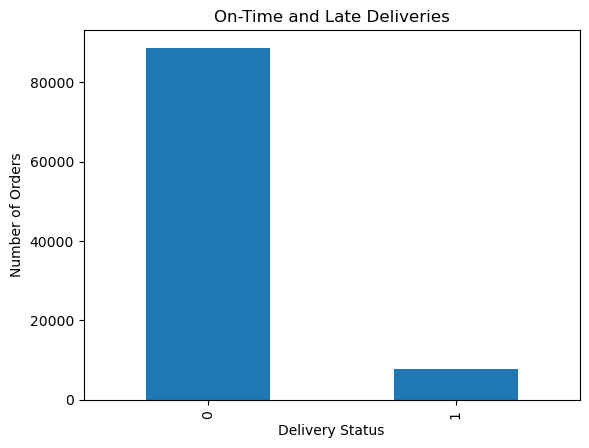

In [16]:
order_data["late_delivery"].value_counts()
order_data["late_delivery"].value_counts(normalize=True)

order_data["late_delivery"].value_counts().plot(kind="bar")
plt.title("On-Time and Late Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.show()



In [22]:
state_delay = (
    order_data.groupby("customer_state")["late_delivery"]
    .mean()
    .sort_values(ascending=False)
)

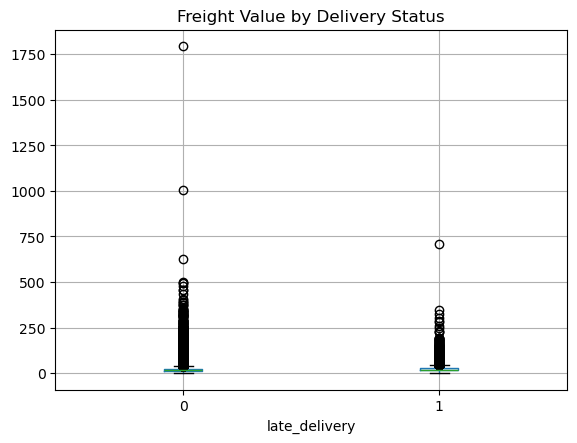

In [21]:
order_data.boxplot(
    column="freight_value",
    by="late_delivery"
)
plt.title("Freight Value by Delivery Status")
plt.suptitle("")
plt.show()

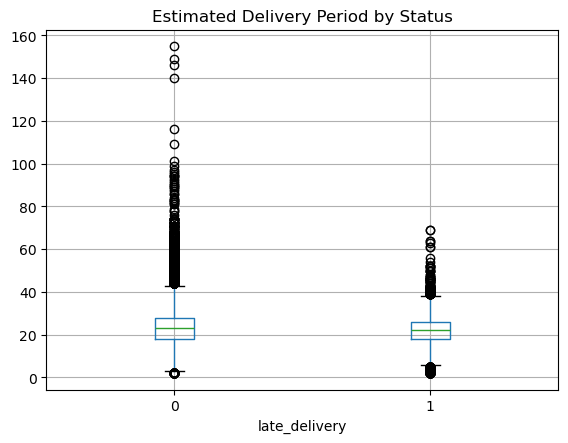

In [19]:
order_data.boxplot(
    column="estimated_delivery_days",
    by="late_delivery"
)
plt.title("Estimated Delivery Period by Status")
plt.suptitle("")
plt.show()

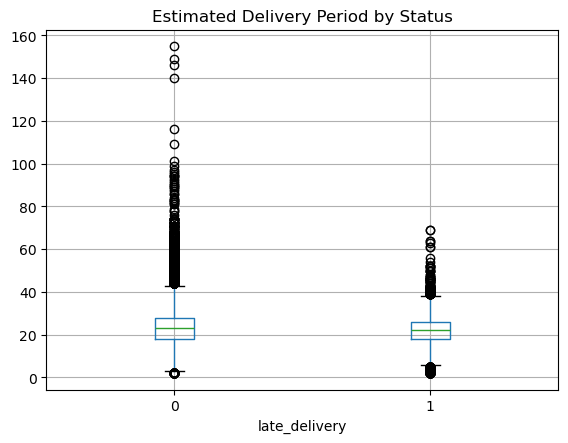

In [20]:
order_data.boxplot(
    column="estimated_delivery_days",
    by="late_delivery"
)
plt.title("Estimated Delivery Period by Status")
plt.suptitle("")
plt.show()

In [23]:
# ============================================================
# STEP 10: SELECT MODEL FEATURES
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("STEP 10: MODEL FEATURE SELECTION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Confirm that the order-level dataframe exists
# ------------------------------------------------------------

if "order_data" not in globals():
    raise NameError(
        "'order_data' does not exist. "
        "Run the order-level aggregation cell first."
    )

print("Order-level dataset shape:", order_data.shape)


# ------------------------------------------------------------
# 2. Define numerical model features
# ------------------------------------------------------------

numerical_features = [
    "price",
    "freight_value",
    "product_weight_g",
    "product_volume_cm3",
    "number_of_items",
    "estimated_delivery_days",
    "purchase_month",
    "purchase_weekday",
    "purchase_hour",
    "same_state"
]


# ------------------------------------------------------------
# 3. Define categorical model features
# ------------------------------------------------------------

categorical_features = [
    "customer_state",
    "seller_state"
]


# ------------------------------------------------------------
# 4. Define the prediction target
# ------------------------------------------------------------

target_column = "late_delivery"


# Combine numerical and categorical feature names
selected_features = (
    numerical_features
    + categorical_features
)


# ------------------------------------------------------------
# 5. Check that all required columns exist
# ------------------------------------------------------------

required_columns = (
    selected_features
    + [target_column]
)

missing_columns = [
    column
    for column in required_columns
    if column not in order_data.columns
]

if missing_columns:
    print("Available columns:")
    print(order_data.columns.tolist())

    raise KeyError(
        "The following required columns are missing: "
        + ", ".join(missing_columns)
    )

print("\nAll required modelling columns are available.")


# ------------------------------------------------------------
# 6. Create the modelling dataframe
# ------------------------------------------------------------

model_data = order_data[
    required_columns
].copy()

print(
    "Initial modelling dataset shape:",
    model_data.shape
)


# ------------------------------------------------------------
# 7. Convert numerical columns to numeric values
# ------------------------------------------------------------

for column in numerical_features:
    model_data[column] = pd.to_numeric(
        model_data[column],
        errors="coerce"
    )


# ------------------------------------------------------------
# 8. Replace infinite values with missing values
# ------------------------------------------------------------

model_data[numerical_features] = (
    model_data[numerical_features]
    .replace([np.inf, -np.inf], np.nan)
)


# ------------------------------------------------------------
# 9. Clean categorical columns
# ------------------------------------------------------------

for column in categorical_features:
    model_data[column] = (
        model_data[column]
        .fillna("UNKNOWN")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # Replace empty strings with UNKNOWN
    model_data[column] = model_data[column].replace(
        "",
        "UNKNOWN"
    )


# ------------------------------------------------------------
# 10. Clean and validate the target
# ------------------------------------------------------------

model_data[target_column] = pd.to_numeric(
    model_data[target_column],
    errors="coerce"
)

# Remove rows where the target is missing
model_data = model_data.dropna(
    subset=[target_column]
).copy()

model_data[target_column] = (
    model_data[target_column]
    .astype(int)
)

target_values = set(
    model_data[target_column].unique()
)

if not target_values.issubset({0, 1}):
    raise ValueError(
        "late_delivery must contain only 0 and 1. "
        f"Current values: {target_values}"
    )


# ------------------------------------------------------------
# 11. Check for invalid negative values
# ------------------------------------------------------------

non_negative_features = [
    "price",
    "freight_value",
    "product_weight_g",
    "product_volume_cm3",
    "number_of_items",
    "estimated_delivery_days"
]

for column in non_negative_features:
    negative_count = (
        model_data[column] < 0
    ).sum()

    if negative_count > 0:
        print(
            f"Warning: {negative_count} negative values "
            f"found in {column}."
        )

        model_data.loc[
            model_data[column] < 0,
            column
        ] = np.nan


# ------------------------------------------------------------
# 12. Validate same_state
# ------------------------------------------------------------

valid_same_state = (
    model_data["same_state"].isin([0, 1])
    | model_data["same_state"].isna()
)

invalid_same_state_count = (
    ~valid_same_state
).sum()

if invalid_same_state_count > 0:
    print(
        f"Warning: {invalid_same_state_count} invalid "
        "same_state values were changed to missing."
    )

    model_data.loc[
        ~valid_same_state,
        "same_state"
    ] = np.nan


# ------------------------------------------------------------
# 13. Create model input X and target y
# ------------------------------------------------------------

X = model_data[
    selected_features
].copy()

y = model_data[
    target_column
].copy()


# ------------------------------------------------------------
# 14. Verify X and y
# ------------------------------------------------------------

if len(X) != len(y):
    raise ValueError(
        "X and y contain different numbers of rows."
    )

if y.nunique() < 2:
    raise ValueError(
        "The target must contain both class 0 and class 1."
    )


# ------------------------------------------------------------
# 15. Display selected features
# ------------------------------------------------------------

print("\nNumerical features:")

for feature in numerical_features:
    print("-", feature)

print("\nCategorical features:")

for feature in categorical_features:
    print("-", feature)

print("\nTarget:")
print("-", target_column)


# ------------------------------------------------------------
# 16. Display final dataset information
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MODELLING DATA")
print("=" * 70)

print("model_data shape:", model_data.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of model features:", X.shape[1])


# ------------------------------------------------------------
# 17. Display target distribution
# ------------------------------------------------------------

target_distribution = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "percentage": (
        y.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

target_distribution.index = [
    "On time (0)",
    "Late (1)"
]

print("\nTarget distribution:")
display(target_distribution)


# ------------------------------------------------------------
# 18. Display missing-value summary
# ------------------------------------------------------------

missing_summary = pd.DataFrame({
    "missing_count": X.isna().sum(),
    "missing_percentage": (
        X.isna()
        .mean()
        .mul(100)
        .round(2)
    )
}).sort_values(
    "missing_count",
    ascending=False
)

print("\nMissing values in selected features:")
display(missing_summary)


# ------------------------------------------------------------
# 19. Display feature data types
# ------------------------------------------------------------

feature_information = pd.DataFrame({
    "feature": X.columns,
    "data_type": X.dtypes.astype(str).values
})

print("\nFeature data types:")
display(feature_information)


# ------------------------------------------------------------
# 20. Preview the model inputs
# ------------------------------------------------------------

print("\nModel input preview:")
display(X.head())

print("\nTarget preview:")
display(y.head())


print("\nStep 10 completed successfully.")
print("X and y are ready for the train-test split.")

STEP 10: MODEL FEATURE SELECTION
Order-level dataset shape: (96470, 14)

All required modelling columns are available.
Initial modelling dataset shape: (96470, 13)

Numerical features:
- price
- freight_value
- product_weight_g
- product_volume_cm3
- number_of_items
- estimated_delivery_days
- purchase_month
- purchase_weekday
- purchase_hour
- same_state

Categorical features:
- customer_state
- seller_state

Target:
- late_delivery

FINAL MODELLING DATA
model_data shape: (96470, 13)
X shape: (96470, 12)
y shape: (96470,)
Number of model features: 12

Target distribution:


,count,percentage
On time (0),88644,91.89
Late (1),7826,8.11



Missing values in selected features:


,missing_count,missing_percentage
price,0,0.0
freight_value,0,0.0
product_weight_g,0,0.0
product_volume_cm3,0,0.0
number_of_items,0,0.0
estimated_delivery_days,0,0.0
purchase_month,0,0.0
purchase_weekday,0,0.0
purchase_hour,0,0.0
same_state,0,0.0



Feature data types:


...


Model input preview:


,price,freight_value,product_weight_g,product_volume_cm3,number_of_items,estimated_delivery_days,purchase_month,purchase_weekday,purchase_hour,same_state,customer_state,seller_state
0,58.90,13.29,650.0,3528.0,1,15,9,2,8,0,RJ,SP
1,239.90,19.93,30000.0,60000.0,1,18,4,2,10,1,SP,SP
2,199.00,17.87,3050.0,14157.0,1,21,1,6,14,1,MG,MG
3,12.99,12.79,200.0,2400.0,1,11,8,2,10,1,SP,SP
4,199.90,18.14,3750.0,42000.0,1,40,2,5,13,0,SP,PR



Target preview:


0    0
1    0
2    0
3    0
4    0
Name: late_delivery, dtype: int64


Step 10 completed successfully.
X and y are ready for the train-test split.


In [36]:
# ============================================================
# STEP 11: TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training input shape:", X_train.shape)
print("Testing input shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training input shape: (77176, 12)
Testing input shape: (19294, 12)
Training target shape: (77176,)
Testing target shape: (19294,)

Training target distribution:
late_delivery
0    70915
1     6261
Name: count, dtype: int64

Testing target distribution:
late_delivery
0    17729
1     1565
Name: count, dtype: int64


In [37]:
# ============================================================
# STEP 12: PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# These lists were created in Step 10
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Numerical features: ['price', 'freight_value', 'product_weight_g', 'product_volume_cm3', 'number_of_items', 'estimated_delivery_days', 'purchase_month', 'purchase_weekday', 'purchase_hour', 'same_state']
Categorical features: ['customer_state', 'seller_state']
Preprocessing pipeline created successfully.


In [38]:
# ============================================================
# STEP 13: TRAIN MODELS
# ============================================================

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


# ------------------------------------------------------------
# Logistic Regression pipeline
# ------------------------------------------------------------

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# Random Forest pipeline
# ------------------------------------------------------------

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# ------------------------------------------------------------
# Train both models
# ------------------------------------------------------------

print("Training Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")


print("\nTraining Random Forest...")

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Training Logistic Regression...
Logistic Regression training completed.

Training Random Forest...
Random Forest training completed.


In [39]:
# ============================================================
# STEP 14: MODEL EVALUATION AND SELECTION
# ============================================================

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

evaluation_results = []


for model_name, trained_model in models.items():

    predictions = trained_model.predict(X_test)

    probabilities = trained_model.predict_proba(
        X_test
    )[:, 1]

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "On time",
                "Late"
            ],
            zero_division=0
        )
    )

    print("Confusion matrix:")
    print(
        confusion_matrix(
            y_test,
            predictions
        )
    )


# Convert the results into a table
model_results = pd.DataFrame(
    evaluation_results
)

model_results = model_results.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

print("\nModel comparison:")
display(
    model_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

Logistic Regression

Classification report:
              precision    recall  f1-score   support

     On time       0.95      0.64      0.77     17729
        Late       0.14      0.64      0.22      1565

    accuracy                           0.64     19294
   macro avg       0.54      0.64      0.50     19294
weighted avg       0.89      0.64      0.72     19294

Confusion matrix:
[[11414  6315]
 [  570   995]]
Random Forest

Classification report:
              precision    recall  f1-score   support

     On time       0.92      1.00      0.96     17729
        Late       0.52      0.04      0.07      1565

    accuracy                           0.92     19294
   macro avg       0.72      0.52      0.51     19294
weighted avg       0.89      0.92      0.89     19294

Confusion matrix:
[[17674    55]
 [ 1505    60]]

Model comparison:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.6432,0.1361,0.6358,0.2242,0.6946
1,Random Forest,0.9191,0.5217,0.0383,0.0714,0.7551


In [40]:
# Select the model with the highest F1-score
best_model_name = model_results.loc[
    0,
    "Model"
]

best_model = models[
    best_model_name
]

print("Selected best model:", best_model_name)
print("Best model variable created successfully.")

Selected best model: Logistic Regression
Best model variable created successfully.


In [41]:
# ============================================================
# STEP 15: SAVE THE FINAL MODEL PIPELINE
# ============================================================

from pathlib import Path
import joblib

# Your notebook is inside the notebooks folder,
# so ../model refers to E:\DataMining\Logistic\model
model_directory = Path("../model")

model_directory.mkdir(
    parents=True,
    exist_ok=True
)

model_path = (
    model_directory
    / "delivery_delay_model.pkl"
)

joblib.dump(
    best_model,
    model_path
)

print("Selected model:", best_model_name)
print("Model pipeline saved successfully.")
print("Saved location:", model_path.resolve())

Selected model: Logistic Regression
Model pipeline saved successfully.
Saved location: E:\DataMining\Logistic\model\delivery_delay_model.pkl


In [42]:
# ============================================================
# TEST THE SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    model_path
)

sample_input = X_test.iloc[[0]].copy()

sample_prediction = loaded_model.predict(
    sample_input
)[0]

sample_probability = loaded_model.predict_proba(
    sample_input
)[0][1]

print("Sample input:")
display(sample_input)

print(
    "Predicted class:",
    int(sample_prediction)
)

print(
    "Late-delivery probability:",
    round(float(sample_probability), 4)
)

Sample input:


,price,freight_value,product_weight_g,product_volume_cm3,number_of_items,estimated_delivery_days,purchase_month,purchase_weekday,purchase_hour,same_state,customer_state,seller_state
61681,99.9,21.65,1150.0,5544.0,1,29,4,0,19,0,SP,PR


Predicted class: 0
Late-delivery probability: 0.297


In [43]:
import sklearn

print(sklearn.__version__)

1.6.1
